# 02 · Visualization — maps from the CRAF'd API

**What this teaches:** how to turn CRAF'd API subsets into PRIO-GRID **pixel maps** — single
months, shared-scale multi-month panels, all three conflict features, regional GAUL-1 zooms,
and cross-country comparisons — using `views_crafdapi.plotting`. The API serves a **global** forecast (every land cell
worldwide) — §0 shows that coverage for historical **and** forecast; later sections zoom
into example regions.

**Audience:** an analyst producing figures from the service. Data comes via `CrafdApiClient`;
plotting via the `plotting` helpers (`plot_pixel_grid`, `shared_norm_from_dfs`,
`make_subplot_grid`, `add_shared_colorbar`).

> **How to run this notebook.** It calls the **live service**, so it needs an **API key**
> (copy `.env.example` to `.env`, set `APPWRITE_DATASTORE_API_KEY`) plus `matplotlib` /
> `geopandas`. For a credential-free map on synthetic data, see `03_offline_demo.ipynb`.
> **What these numbers are.** Conflict-fatality forecasts — an *input/driver* to food-security analysis, **not** a food-security, IPC, or hunger output. **All values are raw fatality counts**; the `lr_`/`pred_` prefixes are legacy VIEWS naming, **not** a log scale. Every served column is defined in the [data dictionary](../docs/api/data_dictionary.md).


## 1. Setup & Authentication

In [1]:
import os
import requests
import matplotlib.pyplot as plt
from dotenv import load_dotenv

from views_crafdapi.time import date_to_month_id, month_id_to_date, month_id_range
from views_crafdapi.client import CrafdApiClient
from views_crafdapi.plotting import (
    plot_pixel_grid,
    shared_norm_from_dfs,
    make_subplot_grid,
    add_shared_colorbar,
)

load_dotenv()  # reads APPWRITE_DATASTORE_API_KEY (and optional VIEWS_API_URL) from .env

API_KEY = os.environ.get("APPWRITE_DATASTORE_API_KEY", "").strip().strip('"')
BASE_URL = os.environ.get("VIEWS_API_URL", "https://crafdapi.viewsforecasting.org")

# Generous timeout: the global coverage fetch (§0) pulls every land cell.
client = CrafdApiClient(BASE_URL, API_KEY, timeout=600)
print("Base URL:", BASE_URL)
print("API key :", "set" if API_KEY else "MISSING — set it in .env")

# Cold-start helper: the FIRST data call on a freshly-(re)deployed server rebuilds the dataset
# (~2-3 min) and can exceed the client timeout; retry once — the server keeps the warmed cache, so
# the retry is fast. Run `scripts/smoke.py` right after a deploy to pre-warm and skip this wait.
def fetch_warm(fn):
    try:
        return fn()
    except requests.exceptions.Timeout:
        print("  server cache was cold — warmed, retrying once…")
        return fn()

Base URL: https://crafdapi.viewsforecasting.org
API key : set


In [2]:
try:
    health = client.health()
    print(f"Status: {health['status']}  |  Appwrite: {health['appwrite_connected']}")
    prov = client.provenance("forecast")
    RUN_ID = prov.get("run_id") or prov.get("name") or "unknown"
    print(f"Forecast run: {RUN_ID}  (produced {prov.get('created_at')})")
except Exception as e:
    RUN_ID = "unknown"
    print(f"Health/provenance unavailable ({e}) — set APPWRITE_DATASTORE_API_KEY in .env.")


Status: healthy  |  Appwrite: True


Forecast run: rusty_bucket_forecasting_20260727_095355  (produced 2026-08-14T18:35:54.962+00:00)


---

## 0 · Global coverage — historical & forecast

The API serves a **global** land grid (the `land_gaul` scope) for both historical and forecast.
The maps below sample countries spanning every inhabited continent — each pixel is a served
PRIO-GRID cell — to show that footprint for historical **and** forecast without pulling every
cell's full posterior. Historical plots the observed `lr_ged_sb`; forecast plots the posterior
mean of `pred_lr_ged_sb`.

In [3]:
import pandas as pd

FORECAST_MONTH = date_to_month_id(2026, 7)   # first month of the run window (2026-07 … 2029-06); advances per run
HIST_MONTH = date_to_month_id(2024, 12)

# Countries spanning every inhabited continent, fetched in ONE request each — a per-country
# loop can silently skip countries while the server loads the dataset, leaving a partial map.
COVERAGE = ["MEX", "COL", "BRA", "UKR", "NGA", "COD", "ETH", "IRQ", "AFG", "MMR", "IND", "IDN"]
hist_cov = fetch_warm(lambda: client.fetch_subset("country", [HIST_MONTH], COVERAGE, data_type="historical"))
fc_cov = fetch_warm(lambda: client.fetch_subset("country", [FORECAST_MONTH], COVERAGE, data_type="forecast",
                                                features=["pred_lr_ged_sb"]))
for label, df in [("historical", hist_cov), ("forecast", fc_cov)]:
    print(f"{label:10s}: {len(df):,} served cells across {df['country_iso_a3'].nunique()} "
          f"countries (globe-spanning sample)")

historical: 8,775 served cells across 12 countries (globe-spanning sample)
forecast  : 8,775 served cells across 12 countries (globe-spanning sample)


In [4]:
# --- Preflight 1/2: is there a key at all? ---
# The setup cell above prints MISSING and continues, so without this the first data call
# fails as `401 ... User (role: guests) missing scopes (["buckets.read"])` — an Appwrite
# message about scopes, for what is actually an absent .env.
# `.env.example`'s placeholder counts as "no key": copying the template and forgetting to edit
# it is the common trap, and it fails as `401 ... not authorized` rather than as a missing key.
# `.env.example` ships the literal "your-api-key-here"; copying the template and
# forgetting to edit it is the common trap, and it fails as 401 rather than as a missing key.
if not API_KEY or API_KEY == "your-api-key-here":
    raise SystemExit(
        "No usable API key.\n\n"
        "The live notebooks read APPWRITE_DATASTORE_API_KEY from a .env at the ROOT OF THIS\n"
        "REPOSITORY (views-crafdapi/.env) — not from views-models.\n\n"
        "Fix:\n"
        "    cp .env.example .env\n"
        "    # then EDIT .env — replace `your-api-key-here` with a real key\n"
        "    #   (request one from the VIEWS team)\n\n"
        "Then restart the kernel and re-run from the top. "
        "03_offline_demo.ipynb needs no key at all."
    )

# --- Preflight 2/2: is the month this notebook asks for inside the served run? ---
_prov = client.provenance("forecast")
_served = _prov.get("run_id") or _prov.get("name") or "unknown run"
_probe = client.fetch_subset("country", [FORECAST_MONTH], ["IDN"],
                             data_type="forecast", features=["pred_lr_ged_sb"])
if len(_probe) == 0:
    raise SystemExit(
        f"Preflight failed: month_id {FORECAST_MONTH} "
        f"({month_id_to_date(FORECAST_MONTH)}) returned no rows from the served run "
        f"'{_served}'.\n\n"
        f"The forecast window advances with each delivery, so a month that worked last "
        f"month may now be outside it.\n"
        f"Fix: change FORECAST_MONTH above to a month inside the current run, then re-run "
        f"from the top.\n"
        f"Run produced: {_prov.get('created_at')}"
    )
print(f"Preflight OK — month {FORECAST_MONTH} "
      f"({month_id_to_date(FORECAST_MONTH)}) is served by run '{_served}'.")


Preflight OK — month 559 (2026-07) is served by run 'rusty_bucket_forecasting_20260727_095355'.


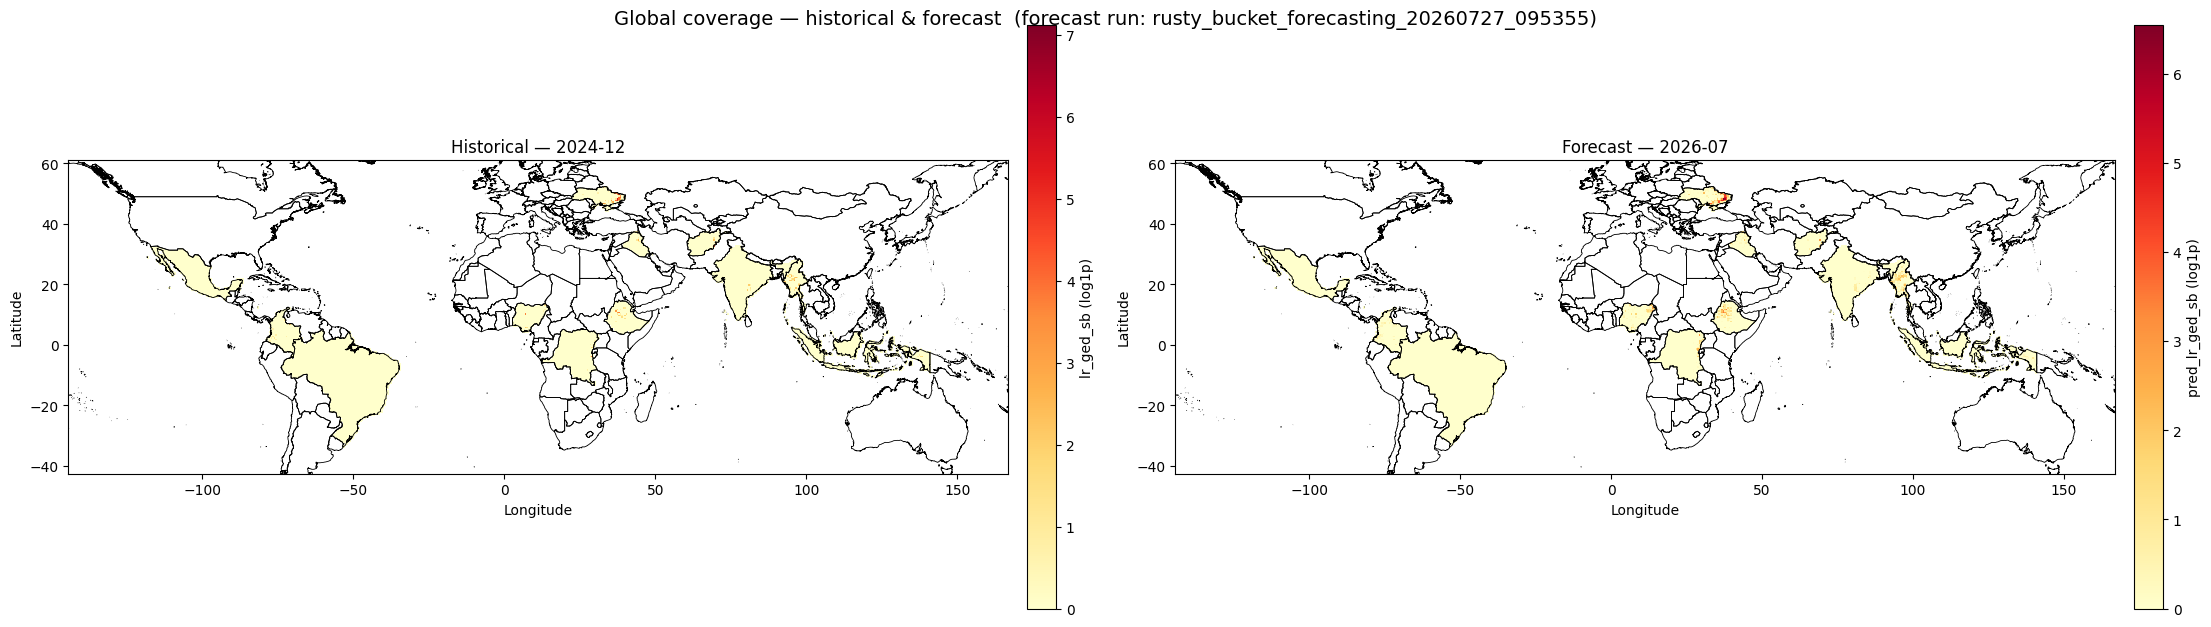

In [5]:
fig, axes = make_subplot_grid(2, cols=2, figsize_per_plot=(11, 6))
plot_pixel_grid(hist_cov, ax=axes[0], lon_col="pg_xcoord", lat_col="pg_ycoord",
                value_col="lr_ged_sb", transform="log1p", cmap="YlOrRd")
axes[0].set_title(f"Historical — {month_id_to_date(HIST_MONTH)}")
plot_pixel_grid(fc_cov, ax=axes[1], lon_col="pg_xcoord", lat_col="pg_ycoord",
                value_col="pred_lr_ged_sb", agg="mean", transform="log1p", cmap="YlOrRd")
axes[1].set_title(f"Forecast — {month_id_to_date(FORECAST_MONTH)}")
fig.suptitle(f"Global coverage — historical & forecast  (forecast run: {RUN_ID})", fontsize=14, y=1.02)
plt.show()

---

## 2. Single-Month Map — Nigeria

Fetch one month of Nigerian data and plot it as a pixel grid with country borders.  
The `plot_pixel_grid` function renders each PRIO-GRID cell as a colored pixel at its centroid coordinates.

In [6]:
df_nga = client.fetch_subset("country", [date_to_month_id(2024, 12)], "NGA")

df_nga.head()

,month_id,priogrid_id,lr_ged_sb,lr_ged_ns,lr_ged_os,pg_xcoord,pg_ycoord,country_iso_a3,admin1_gaul1_code,admin1_gaul1_name,admin1_gaul0_code,admin1_gaul0_name,admin2_gaul2_code,admin2_gaul2_name
0,540,135732,0.0,0.0,0.0,5.75,4.25,NGA,1522.0,Bayelsa,151.0,Nigeria,104747.0,Southern Ijaw
1,540,135733,0.0,0.0,0.0,6.25,4.25,NGA,1522.0,Bayelsa,151.0,Nigeria,104741.0,Brass
2,540,135734,0.0,0.0,0.0,6.75,4.25,NGA,1549.0,Rivers,151.0,Nigeria,105315.0,Akuku Toru
3,540,135735,0.0,0.0,0.0,7.25,4.25,NGA,1549.0,Rivers,151.0,Nigeria,105318.0,Bonny
4,540,135736,0.0,0.0,0.0,7.75,4.25,NGA,1549.0,Rivers,151.0,Nigeria,105331.0,Opobo/Nkoro


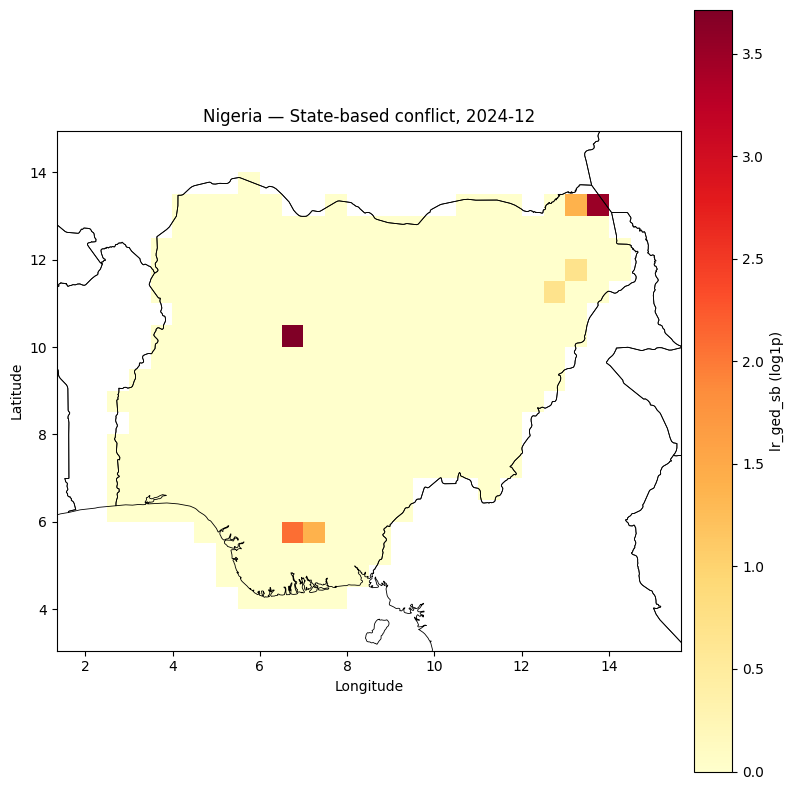

In [7]:
fig, ax, im = plot_pixel_grid(
    df_nga,
    lon_col="pg_xcoord",
    lat_col="pg_ycoord",
    value_col="lr_ged_sb",
    transform="log1p",
    cmap="YlOrRd",
    figsize=(8, 8),
)
ax.set_title(f"Nigeria — State-based conflict, {month_id_to_date(date_to_month_id(2024, 12))}")
plt.show()

---

## 3. Multi-Month Panels

Compare conflict intensity across consecutive months using a shared color scale.  
This is useful for spotting temporal shifts — new hotspots appearing, existing ones cooling down.

In [8]:
months_q4 = month_id_range(2024, 10, 2024, 12)
df_q4 = client.fetch_subset("country", months_q4, "NGA")

dfs_by_month = [df_q4[df_q4["month_id"] == m] for m in months_q4]
print(f"Rows per month: {[len(d) for d in dfs_by_month]}")

Rows per month: [310, 310, 310]


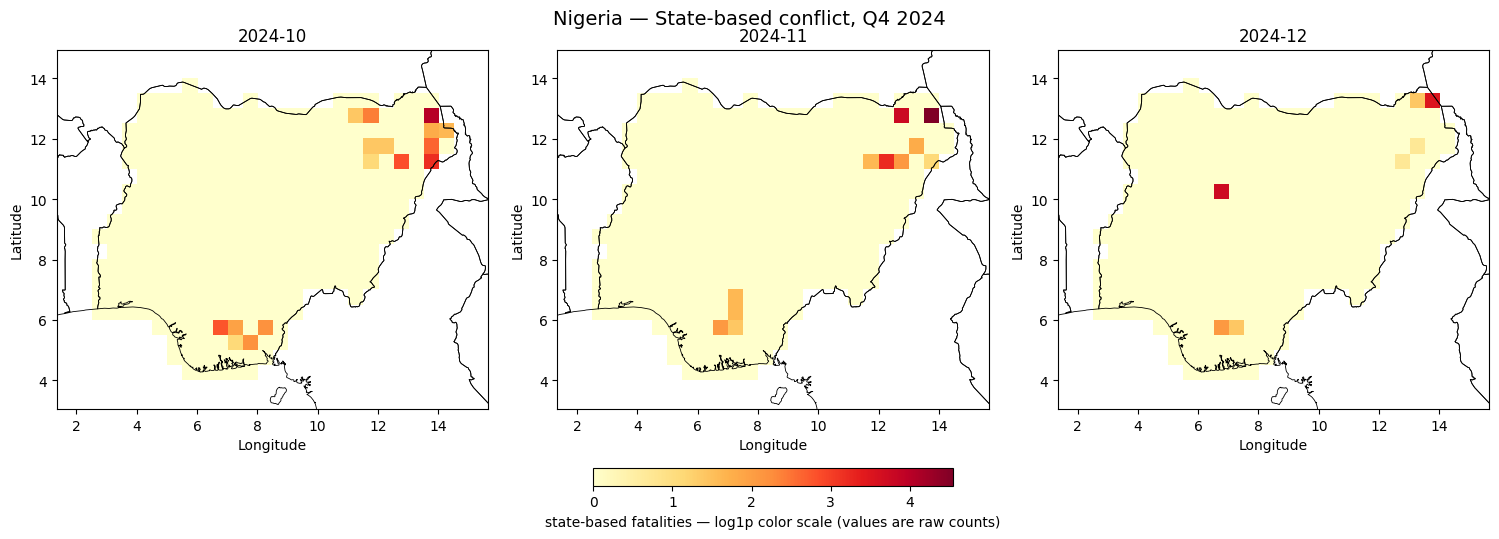

In [9]:
AGG = "mean"
TRANSFORM = "log1p"
CMAP = "YlOrRd"

norm = shared_norm_from_dfs(
    dfs_by_month,
    value_col="lr_ged_sb",
    agg=AGG,
    transform=TRANSFORM,
)

fig, axes = make_subplot_grid(len(dfs_by_month), cols=3, figsize_per_plot=(5, 5))

for ax, subdf, mid in zip(axes, dfs_by_month, months_q4):
    plot_pixel_grid(
        subdf, ax=ax,
        lon_col="pg_xcoord", lat_col="pg_ycoord",
        value_col="lr_ged_sb",
        agg=AGG, transform=TRANSFORM,
        norm=norm, cmap=CMAP,
        colorbar=False,
    )
    ax.set_title(month_id_to_date(mid))

add_shared_colorbar(fig, list(axes), norm, CMAP, label="state-based fatalities — log1p color scale (values are raw counts)")
fig.suptitle("Nigeria — State-based conflict, Q4 2024", fontsize=14, y=1.05)
plt.show()

---

## 4. All Three Features Side by Side

The API serves three conflict features:
- `lr_ged_sb` — state-based armed conflict
- `lr_ged_ns` — non-state conflict  
- `lr_ged_os` — one-sided violence

Plotting them together reveals which type of violence dominates in different areas.

In [10]:
mid = date_to_month_id(2024, 12)
df_all = client.fetch_subset("country", [mid], "NGA")

features = ["lr_ged_sb", "lr_ged_ns", "lr_ged_os"]
feature_labels = ["State-based", "Non-state", "One-sided violence"]

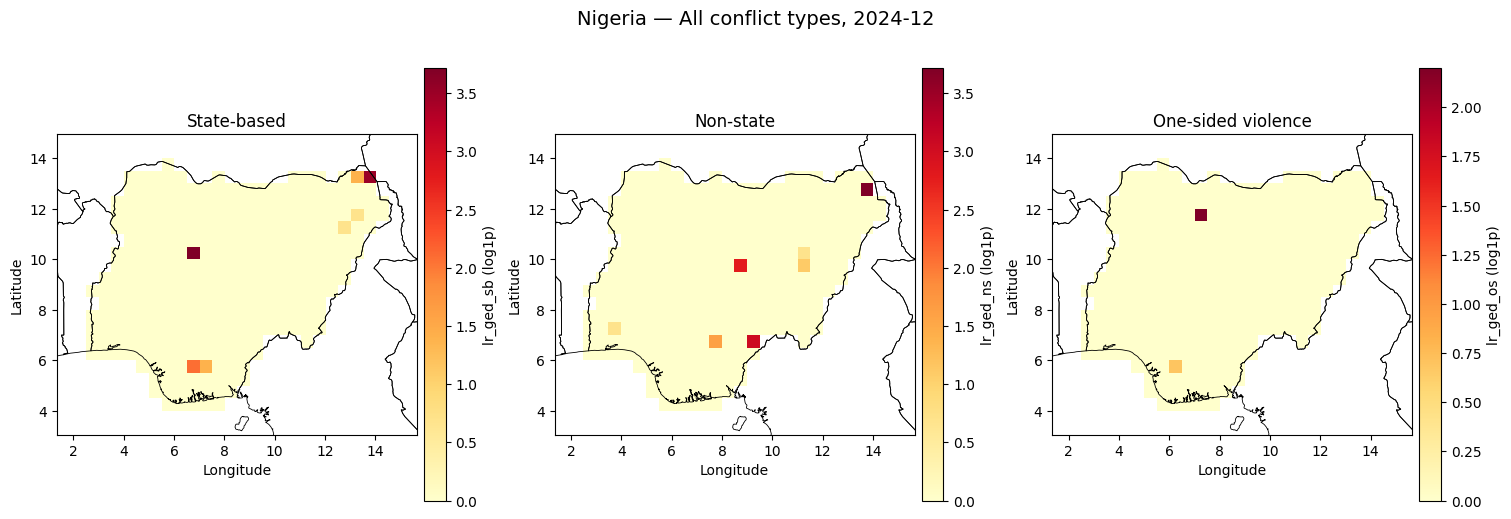

In [11]:
CMAP = "YlOrRd"
TRANSFORM = "log1p"

fig, axes = make_subplot_grid(3, cols=3, figsize_per_plot=(5, 5))

for ax, feat, label in zip(axes, features, feature_labels):
    plot_pixel_grid(
        df_all, ax=ax,
        lon_col="pg_xcoord", lat_col="pg_ycoord",
        value_col=feat,
        transform=TRANSFORM, cmap=CMAP,
    )
    ax.set_title(label)

fig.suptitle(f"Nigeria — All conflict types, {month_id_to_date(mid)}", fontsize=14, y=1.05)
plt.show()

---

## 5. Regional Focus — GAUL-1 Zoom

Zoom into a specific first-level administrative region.  
First we discover the GAUL-1 codes for a country, then fetch and plot individual regions.

In [12]:
mid = date_to_month_id(2024, 12)
df_nga_full = client.fetch_subset("country", [mid], "NGA")

gaul1_regions = (
    df_nga_full[["admin1_gaul1_code", "admin1_gaul1_name"]]
    .drop_duplicates()
    .sort_values("admin1_gaul1_name")
)

print(f"GAUL-1 regions in Nigeria ({len(gaul1_regions)}):")
for _, row in gaul1_regions.head(10).iterrows():
    print(f"  {int(row['admin1_gaul1_code']):>6}  {row['admin1_gaul1_name']}")
print("  ...")

GAUL-1 regions in Nigeria (36):
    1517  Abia
    1518  Adamawa
    1519  Akwa Lbom
    1521  Bauchi
    1522  Bayelsa
    1523  Benue
    1524  Borno
    1525  Cross River
    1526  Delta
    1527  Ebonyi
  ...


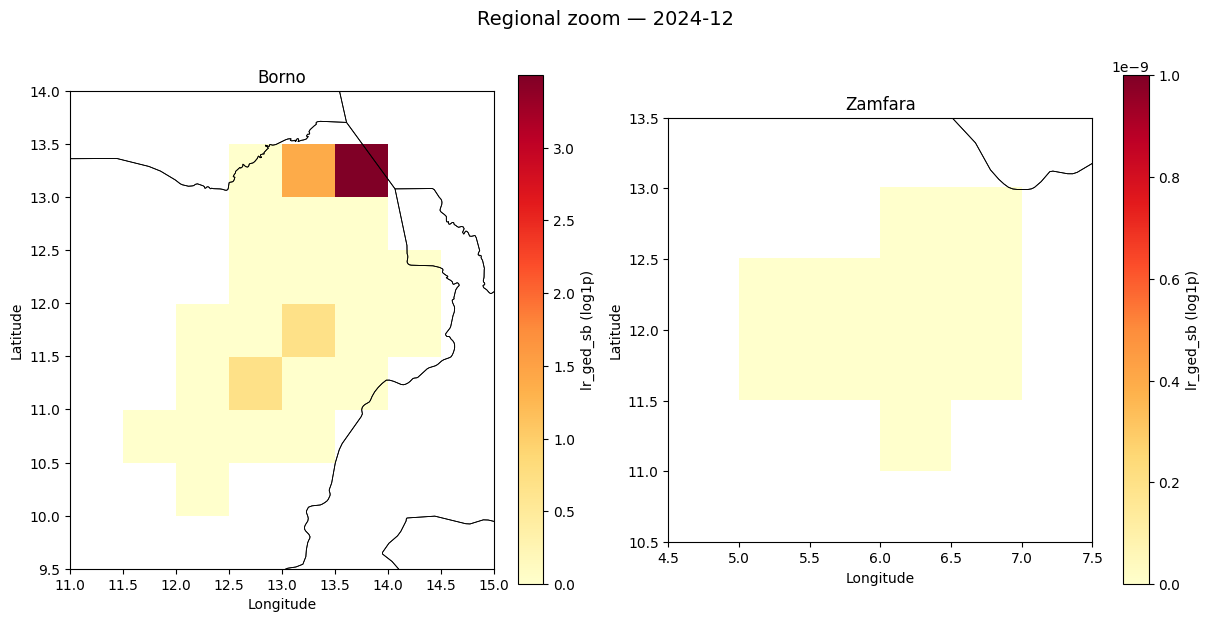

In [13]:
focus_regions = gaul1_regions[gaul1_regions["admin1_gaul1_name"].isin(["Borno", "Zamfara"])]
codes = focus_regions["admin1_gaul1_code"].astype(int).tolist()
names = focus_regions["admin1_gaul1_name"].tolist()

df_regions = client.fetch_subset("gaul1", [mid], codes)
dfs_region = [df_regions[df_regions["admin1_gaul1_code"] == c] for c in codes]

fig, axes = make_subplot_grid(2, cols=2, figsize_per_plot=(6, 6))

for ax, subdf, name in zip(axes, dfs_region, names):
    plot_pixel_grid(
        subdf, ax=ax,
        lon_col="pg_xcoord", lat_col="pg_ycoord",
        value_col="lr_ged_sb",
        transform="log1p", cmap="YlOrRd",
    )
    ax.set_title(name)

fig.suptitle(f"Regional zoom — {month_id_to_date(mid)}", fontsize=14, y=1.05)
plt.show()

---

## 6. Multi-Country Comparison

Compare conflict patterns across multiple countries for the same time period.  
A shared color scale ensures the intensities are directly comparable. Includes Colombia
(`COL`) — a non-African country — since the forecast is global.

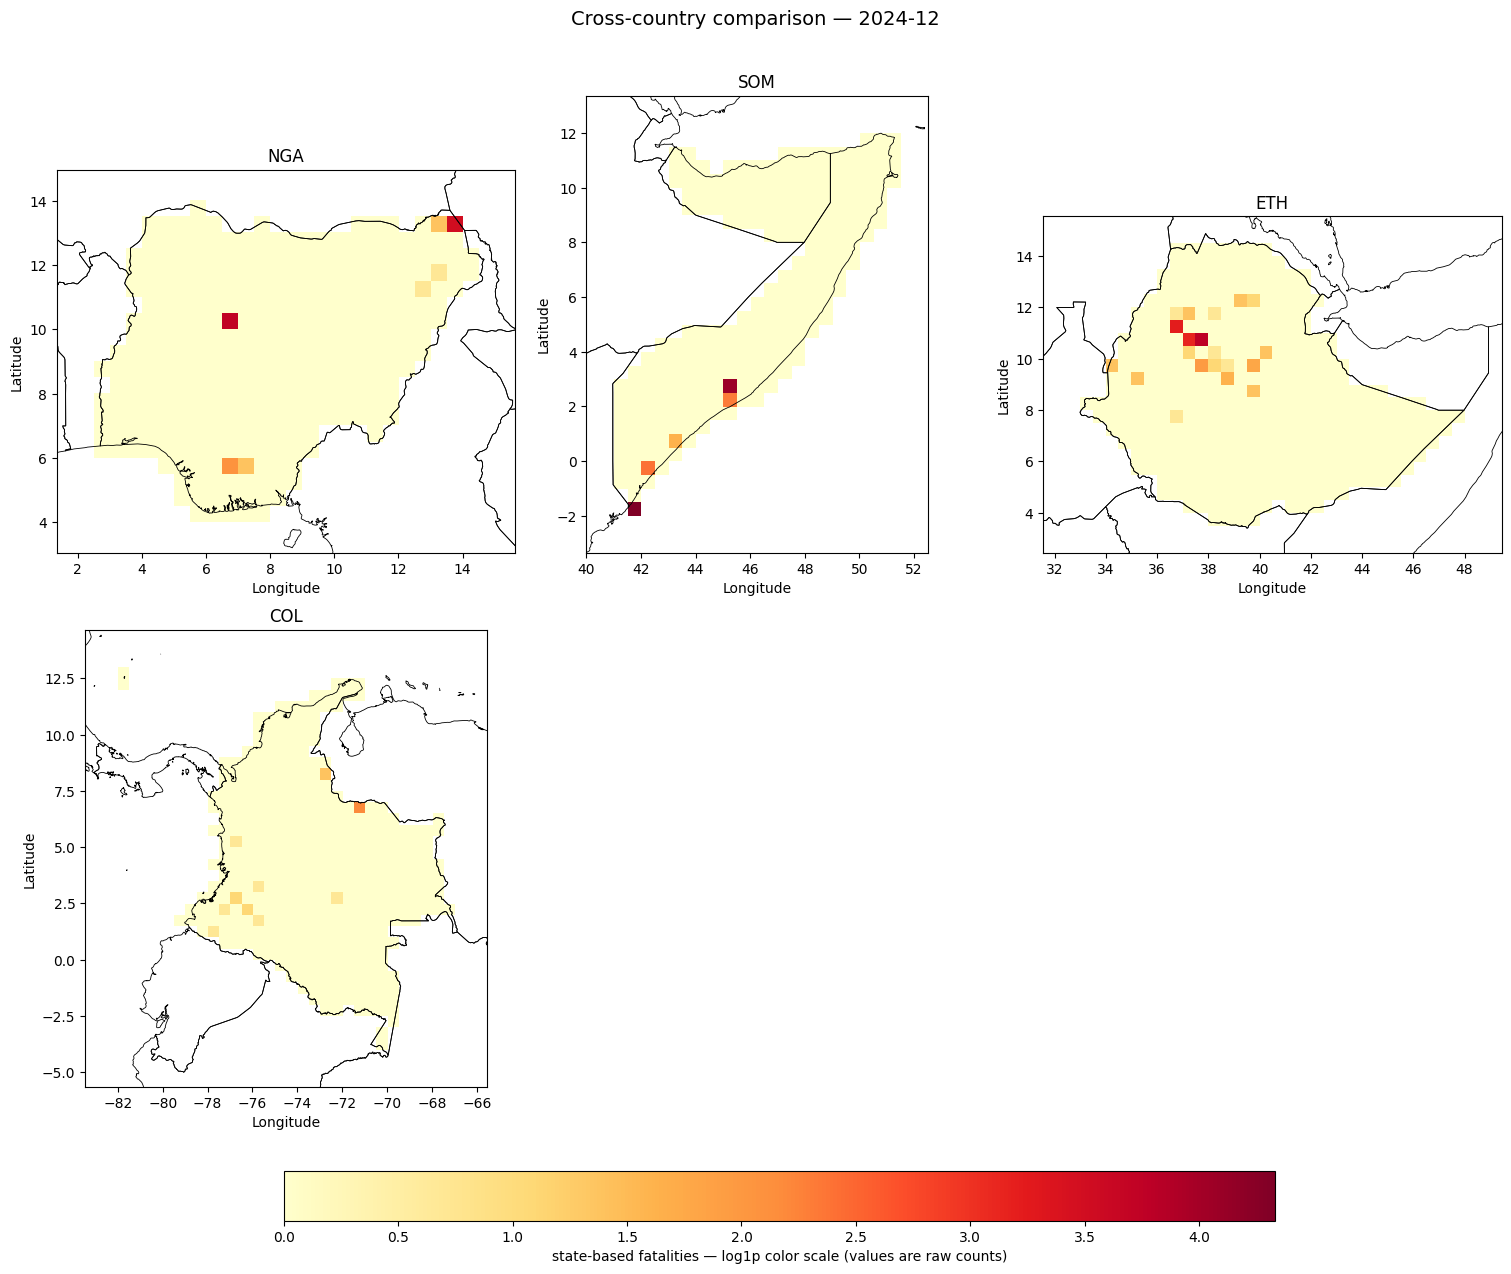

In [14]:
mid = date_to_month_id(2024, 12)
countries = ["NGA", "SOM", "ETH", "COL"]  # incl. Colombia — the forecast is global

# One atomic multi-country request — a per-country loop can silently skip countries while the
# server loads the dataset (see §0). Split locally for the per-panel plots.
df_all = fetch_warm(lambda: client.fetch_subset("country", [mid], countries))
dfs_country = [df_all[df_all["country_iso_a3"] == iso] for iso in countries]

CMAP = "YlOrRd"
TRANSFORM = "log1p"

norm = shared_norm_from_dfs(dfs_country, value_col="lr_ged_sb", transform=TRANSFORM)

fig, axes = make_subplot_grid(len(countries), cols=3, figsize_per_plot=(5, 6))

for ax, df_iso, iso in zip(axes, dfs_country, countries):
    plot_pixel_grid(
        df_iso, ax=ax,
        lon_col="pg_xcoord", lat_col="pg_ycoord",
        value_col="lr_ged_sb",
        transform=TRANSFORM, norm=norm, cmap=CMAP,
        colorbar=False,
    )
    ax.set_title(iso)

add_shared_colorbar(fig, list(axes), norm, CMAP, label="state-based fatalities — log1p color scale (values are raw counts)")
fig.suptitle(f"Cross-country comparison — {month_id_to_date(mid)}", fontsize=14, y=1.05)
plt.show()

## Next steps

- **`01_quickstart.ipynb`** — the full API: historical + forecast subsetting and HDI/MAP uncertainty.
- **`03_offline_demo.ipynb`** — the same analytics and a map on **synthetic data, no key required**.
- `views_crafdapi.plotting` supports custom colormaps, shared normalization, subplot grids, and border overlays.